# RQ3: Membership Inference and Memorization Defense

**Research Question**: How effectively does the hybrid privacy framework reduce membership inference attack success and memorization leakage compared with non-private and uniform-DP baselines?

## Methodology:
1. Prepare comparable model/data variants for attack evaluation (non-private baseline, uniform-DP baseline, and hybrid privacy variant).
2. Run privacy risk probes with a consistent setup across variants:
   - **Membership Inference Attack (MIA)**: estimate attack success via ROC-AUC style separation between member/non-member behavior.
   - **Memorization Leakage Checks**: quantify potential leakage signals under controlled prompts/examples.
3. Evaluate and report outcomes both overall and across relevant slices used in this notebook (for example, preprocessing/sensitivity groupings where applicable).
4. Compare privacy-utility trade-offs to determine whether hybrid privacy lowers leakage risk while preserving task performance.

In [ ]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 21.0 MB/s eta 0:00:00


In [ ]:
import os
import sys
import importlib.util
from pathlib import Path

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import auc, roc_curve, roc_auc_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully")
except:
    print("Running outside Colab or Drive already mounted")


PROJECT_ROOT = Path('/content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots')

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project root not found at: {PROJECT_ROOT}")

print(f"Project root: {PROJECT_ROOT}")


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# Import hybrid DP utilities
try:
    from src.utils.hybrid_dp_utils import HybridDPCoach
    print("HybridDPCoach imported using standard module import")
except Exception as e:
    print("Standard import failed. Trying fallback method...")

    UTIL_PATH = PROJECT_ROOT / 'src' / 'utils' / 'hybrid_dp_utils.py'

    if not UTIL_PATH.exists():
        raise FileNotFoundError(f"Utility file not found at: {UTIL_PATH}")

    spec = importlib.util.spec_from_file_location('hybrid_dp_utils', UTIL_PATH)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    HybridDPCoach = module.HybridDPCoach
    print(f"HybridDPCoach loaded via fallback from: {UTIL_PATH}")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Mounted at /content/drive
Google Drive mounted successfully
Project root: /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots
HybridDPCoach imported using standard module import
Using device: cuda


In [ ]:
from pathlib import Path

def find_project_root(start_dir):
    start = Path(start_dir).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'data').exists() and (candidate / 'src').exists():
            return candidate
    return None

colab_candidates = [
    Path('/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots'),
    Path('/content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots'),
    Path('/content/drive/MyDrive/content')
 ]
project_root = next((c for c in colab_candidates if c.exists()), None)
PROJECT_ROOT = project_root or find_project_root(Path.cwd()) or Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'go_emotions_dataset.csv'
CLEANED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'go_emotions_cleaned.csv'

MODEL_DIR_CANDIDATES = [
    Path('/content/drive/MyDrive/models/rq1_variants'),
    Path('/content/drive/MyDrive/content/models/rq1_variants'),
    PROJECT_ROOT / 'models' / 'rq1_variants'
 ]
MODEL_DIR = next((p for p in MODEL_DIR_CANDIDATES if p.exists()), MODEL_DIR_CANDIDATES[0])

OUTPUT_DIR = PROJECT_ROOT / 'models' / 'rq2_rq3_attacks'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'rq2_rq3'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print(f"RQ1 model dir selected: {MODEL_DIR}")

# Load data
df_raw = pd.read_csv(RAW_PATH)
df_cleaned = pd.read_csv(CLEANED_PATH)


df = df_raw.merge(df_cleaned[['id', 'clean_text']], on='id', how='inner')
print(f"Dataset: {df.shape}")

Project root: /content/drive/MyDrive/content/Hybrid-DP-Approach-For-Mental-Health-Chatbots
RQ1 model dir selected: /content/drive/MyDrive/models/rq1_variants
Dataset: (209190, 32)


Create 4 Preprocessing Variants

In [4]:
# Identify emotion columns
meta_cols = {'id', 'text', 'example_very_unclear', 'clean_text'}
emotion_cols = [col for col in df_raw.columns if col not in meta_cols]

# Create 4 preprocessing variants
df['v0_raw'] = df['text'].astype(str).str.lower()
df['v1_masked'] = df['clean_text']

# V2: Length truncation (256 chars)
MAX_LENGTH_V2 = 256
df['v2_length'] = df['text'].astype(str).str.lower().str[:MAX_LENGTH_V2]

# V3: Combined (masked + length)
df['v3_combined'] = df['clean_text'].str[:MAX_LENGTH_V2]

print(" 4 preprocessing variants created")
print(f"  V0 (raw): {df['v0_raw'].str.len().mean():.0f} chars avg")
print(f"  V1 (masked): {df['v1_masked'].str.len().mean():.0f} chars avg")
print(f"  V2 (length): {df['v2_length'].str.len().mean():.0f} chars avg")
print(f"  V3 (combined): {df['v3_combined'].str.len().mean():.0f} chars avg")

 4 preprocessing variants created
  V0 (raw): 70 chars avg
  V1 (masked): 65 chars avg
  V2 (length): 70 chars avg
  V3 (combined): 65 chars avg


Membership Inference Attack (MIA)

In [5]:
def build_rq1_like_split_ids(df_in, emotion_cols_in, seed=42):
    """
    Reconstruct a deterministic split close to RQ1 protocol:
    stratify by total active emotions using qcut bins.
    """
    from sklearn.model_selection import train_test_split

    score = df_in[emotion_cols_in].sum(axis=1)
    bins = pd.qcut(score, q=3, duplicates='drop')

    idx = np.arange(len(df_in))
    train_idx, temp_idx = train_test_split(
        idx,
        test_size=0.4,
        random_state=seed,
        stratify=bins
    )
    temp_bins = bins.iloc[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        random_state=seed,
        stratify=temp_bins
    )

    train_ids = set(df_in.iloc[train_idx]['id'].tolist())
    val_ids = set(df_in.iloc[val_idx]['id'].tolist())
    test_ids = set(df_in.iloc[test_idx]['id'].tolist())
    return train_ids, val_ids, test_ids


def prepare_mia_data_from_ids(df_in, variant_col, emotion_cols_in, train_ids, test_ids):
    """
    Build member/non-member data from shared ID sets so all variants use
    identical membership labels.
    """
    train_df = df_in[df_in['id'].isin(train_ids)]
    test_df = df_in[df_in['id'].isin(test_ids)]

    train_texts = train_df[variant_col].values
    train_labels = train_df[emotion_cols_in].values.astype(np.float32)
    test_texts = test_df[variant_col].values
    test_labels = test_df[emotion_cols_in].values.astype(np.float32)

    return {
        'train': (train_texts, train_labels),
        'test': (test_texts, test_labels),
        'train_ids': sorted(train_ids),
        'test_ids': sorted(test_ids)
    }


# Shared split for all attacks/variants (align membership semantics).
RQ1_SPLIT_SEED = 42
train_ids_shared, val_ids_shared, test_ids_shared = build_rq1_like_split_ids(
    df, emotion_cols, seed=RQ1_SPLIT_SEED
)
print(
    f"Shared split sizes | train={len(train_ids_shared)} "
    f"val={len(val_ids_shared)} test={len(test_ids_shared)}"
)

# Prepare MIA data for each variant from the same train/test IDs.
mia_datasets = {}
for variant in ['v0_raw', 'v1_masked', 'v2_length', 'v3_combined']:
    mia_datasets[variant] = prepare_mia_data_from_ids(
        df, variant, emotion_cols, train_ids_shared, test_ids_shared
    )
    print(f" MIA data prepared for {variant} (shared split)")

Shared split sizes | train=54673 val=31383 test=31437
 MIA data prepared for v0_raw (shared split)
 MIA data prepared for v1_masked (shared split)
 MIA data prepared for v2_length (shared split)
 MIA data prepared for v3_combined (shared split)


MIA: Extract Model Confidence Scores

In [6]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = torch.FloatTensor(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': self.labels[idx]
        }

def _binary_entropy_mean(probs, eps=1e-12):
    probs = torch.clamp(probs, eps, 1.0 - eps)
    ent = -(probs * torch.log(probs) + (1.0 - probs) * torch.log(1.0 - probs))
    return ent.mean(dim=1)

def extract_mia_features(model_name, tokenizer, model, train_data, test_data):
    """
    Extract MIA features for member/non-member attack models.
    Returns per-sample arrays for both train and test partitions.
    """
    model.eval()

    train_texts, train_labels = train_data
    test_texts, test_labels = test_data

    train_dataset = EmotionDataset(train_texts, train_labels, tokenizer)
    test_dataset = EmotionDataset(test_texts, test_labels, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16)
    test_loader = DataLoader(test_dataset, batch_size=16)

    loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none')

    def _collect_features(loader, split_name='train'):
        rows = []
        with torch.no_grad():
            for batch in tqdm(loader, desc=f'Extracting {model_name} {split_name} features'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits

                if logits.shape[1] != labels.shape[1]:
                    labels = labels[:, :logits.shape[1]]

                probs = torch.sigmoid(logits)
                losses = loss_fn(logits, labels).mean(dim=1)
                entropy = _binary_entropy_mean(probs)
                max_prob = probs.max(dim=1).values
                min_prob = probs.min(dim=1).values
                margin = max_prob - min_prob

                batch_rows = torch.stack([
                    losses,
                    max_prob,
                    entropy,
                    margin
                ], dim=1)
                rows.append(batch_rows.detach().cpu().numpy())

        if not rows:
            return np.zeros((0, 4), dtype=np.float32)
        return np.concatenate(rows, axis=0).astype(np.float32)

    train_features = _collect_features(train_loader, split_name='train')
    test_features = _collect_features(test_loader, split_name='test')
    return train_features, test_features

print('MIA feature extraction function ready')

MIA feature extraction function ready


Load Pre-trained Models from RQ1 and Perform MIA

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def _tpr_at_target_fpr(fpr, tpr, target_fpr):
    fpr = np.asarray(fpr, dtype=float)
    tpr = np.asarray(tpr, dtype=float)
    if len(fpr) == 0:
        return np.nan
    if target_fpr <= fpr.min():
        return float(tpr[np.argmin(fpr)])
    if target_fpr >= fpr.max():
        return float(tpr[np.argmax(fpr)])
    return float(np.interp(target_fpr, fpr, tpr))


def compute_attack_metrics(y_true, y_score):
    auc_val = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return {
        'auc': float(auc_val),
        'advantage': float(2.0 * auc_val - 1.0),
        'tpr_at_fpr_1pct': _tpr_at_target_fpr(fpr, tpr, 0.01),
        'tpr_at_fpr_5pct': _tpr_at_target_fpr(fpr, tpr, 0.05),
        'fpr': fpr,
        'tpr': tpr
    }


def evaluate_mia_attack_suite(train_features, test_features, seed=42):
    """
    Evaluate two attacks:
    1) Loss-threshold attack on holdout
    2) Logistic attack using multi-feature vectors on holdout
    """
    X_member = np.asarray(train_features, dtype=np.float32)
    X_nonmember = np.asarray(test_features, dtype=np.float32)

    y_member = np.ones(len(X_member), dtype=np.int32)
    y_nonmember = np.zeros(len(X_nonmember), dtype=np.int32)

    X = np.vstack([X_member, X_nonmember])
    y = np.concatenate([y_member, y_nonmember])

    if len(np.unique(y)) < 2 or len(X) < 20:
        return None

    idx = np.arange(len(X))
    idx_train, idx_holdout = train_test_split(
        idx, test_size=0.35, random_state=seed, stratify=y
    )

    X_holdout = X[idx_holdout]
    y_holdout = y[idx_holdout]

    # Attack 1: threshold on negative loss (feature 0).
    loss_scores = -X_holdout[:, 0]
    m_loss = compute_attack_metrics(y_holdout, loss_scores)

    # Attack 2: logistic over all extracted features.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X[idx_train])
    X_holdout_scaled = scaler.transform(X_holdout)
    clf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=seed)
    clf.fit(X_train_scaled, y[idx_train])
    lr_scores = clf.predict_proba(X_holdout_scaled)[:, 1]
    m_lr = compute_attack_metrics(y_holdout, lr_scores)

    if m_lr['auc'] >= m_loss['auc']:
        best = m_lr
        best_name = 'logreg_features'
    else:
        best = m_loss
        best_name = 'loss_threshold'

    return {
        'loss_attack': m_loss,
        'logreg_attack': m_lr,
        'best_attack': best_name,
        'best_metrics': best,
        'holdout_size': int(len(y_holdout))
    }


# Map variants to RQ1 model names
variant_to_model = {
    'v0_raw': 'V0_BASELINE_best.pt',
    'v1_masked': 'V1_ANONYM_best.pt',
    'v2_length': 'V2_DP_SGD_best.pt',
    'v3_combined': 'V3_HYBRID_best.pt'
}


RQ2_MODELS_ROOT = Path('/content/drive/MyDrive/content/models_rq2')
variant_dir_candidates = {
    'v0_raw': ['v0_baseline'],
    'v1_masked': ['v1_anonym', 'v1_masked'],
    'v2_length': ['v2_dp_sgd', 'v2_length'],
    'v3_combined': ['v3_hybrid', 'v3_combined']
}

def get_latest_checkpoint_dir(base_dir):
    if not base_dir.exists():
        return None
    checkpoints = []
    for p in base_dir.glob('checkpoint-*'):
        try:
            step = int(p.name.split('-')[1])
            checkpoints.append((step, p))
        except Exception:
            continue
    if not checkpoints:
        return None
    return sorted(checkpoints, key=lambda x: x[0])[-1][1]

def resolve_checkpoint_dir(variant):
    for name in variant_dir_candidates.get(variant, []):
        base = RQ2_MODELS_ROOT / name
        ckpt = get_latest_checkpoint_dir(base)
        if ckpt is not None:
            return ckpt
    return None

def load_model_and_tokenizer(model_ref):
    if model_ref is None:
        return None, None, None
    model_ref = Path(model_ref)
    if model_ref.is_dir():
        tokenizer = AutoTokenizer.from_pretrained(model_ref)
        model = AutoModelForSequenceClassification.from_pretrained(model_ref)
        return model, tokenizer, model.config.num_labels
    if model_ref.is_file():
        state_dict = torch.load(model_ref, map_location=device)
        num_labels = state_dict.get('classifier.out_proj.weight', torch.zeros(len(emotion_cols))).shape[0]
        tokenizer = AutoTokenizer.from_pretrained('roberta-base')
        model = AutoModelForSequenceClassification.from_pretrained(
            'roberta-base', num_labels=num_labels, problem_type='multi_label_classification'
        )
        model.load_state_dict(state_dict, strict=False)
        return model, tokenizer, num_labels
    return None, None, None

# Perform MIA for each variant
mia_results_all = []
missing_models = []

print(f'Model dir: {MODEL_DIR}')

for variant, model_file in variant_to_model.items():
    print(f'\nPerforming MIA on {variant}...')
    model_ref = resolve_checkpoint_dir(variant)
    if model_ref is None:
        model_ref = Path(MODEL_DIR) / model_file
    if not Path(model_ref).exists():
        print(f'  Model not found: {model_ref}')
        missing_models.append(str(model_ref))
        continue

    model, tokenizer, num_labels = load_model_and_tokenizer(model_ref)
    if model is None:
        continue
    model.to(device)

    train_texts, train_labels = mia_datasets[variant]['train']
    test_texts, test_labels = mia_datasets[variant]['test']

    train_features, test_features = extract_mia_features(
        variant, tokenizer, model, (train_texts, train_labels), (test_texts, test_labels)
    )
    suite = evaluate_mia_attack_suite(train_features, test_features, seed=42)
    if suite is None:
        print('  Skipping due to insufficient data for attack evaluation')
        continue

    best = suite['best_metrics']
    loss_attack = suite['loss_attack']
    logreg_attack = suite['logreg_attack']

    mia_results_all.append({
        'variant': variant,
        'mia_auc': best['auc'],
        'mia_attack_advantage': best['advantage'],
        'tpr_at_fpr_1pct': best['tpr_at_fpr_1pct'],
        'tpr_at_fpr_5pct': best['tpr_at_fpr_5pct'],
        'best_attack': suite['best_attack'],
        'loss_auc': loss_attack['auc'],
        'logreg_auc': logreg_attack['auc'],
        'holdout_size': suite['holdout_size'],
        'fpr': best['fpr'],
        'tpr': best['tpr']
    })
    print(
        f"  Best attack: {suite['best_attack']} | "
        f"AUC={best['auc']:.4f}, Adv={best['advantage']:.4f}, "
        f"TPR@1%FPR={best['tpr_at_fpr_1pct']:.4f}"
    )

    model.cpu()
    torch.cuda.empty_cache()

if mia_results_all:
    mia_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ['fpr', 'tpr']}
        for r in mia_results_all
    ])
    mia_df.to_csv(os.path.join(REPORT_DIR, 'rq3_mia_results.csv'), index=False)
    print('\nSaved enhanced MIA results to rq3_mia_results.csv')

Model dir: /content/drive/MyDrive/models/rq1_variants

Performing MIA on v0_raw...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting v2_length test features: 100%|██████████| 7461/7461 [03:51<00:00, 32.17it/s]


  Best attack: logreg_features | AUC=0.5073, Adv=0.0145, TPR@1%FPR=0.0103

Performing MIA on v3_combined...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting v3_combined test features: 100%|██████████| 7461/7461 [03:50<00:00, 32.41it/s]


  Best attack: loss_threshold | AUC=0.5069, Adv=0.0139, TPR@1%FPR=0.0106

Saved enhanced MIA results to rq3_mia_results.csv


Canary Insertion Attack

In [8]:
def canary_insertion_attack(df, variant_col, emotion_cols, tokenizer, model, num_canaries=50):
    """
    Inject canary samples and test if they have lower loss.
    """
    canary_texts = [f"[CANARY_{i}] this is a test sentence about emotions" for i in range(num_canaries)]
    canary_labels = np.zeros((num_canaries, len(emotion_cols)))
    canary_labels[:, 0] = 1

    non_canary_idx = np.random.choice(len(df), num_canaries, replace=False)
    non_canary_texts = df[variant_col].iloc[non_canary_idx].values
    non_canary_labels = df[emotion_cols].iloc[non_canary_idx].values.astype(np.float32)

    model.eval()
    dataset_canary = EmotionDataset(canary_texts, canary_labels, tokenizer)
    dataset_non_canary = EmotionDataset(non_canary_texts, non_canary_labels, tokenizer)

    loader_canary = DataLoader(dataset_canary, batch_size=16)
    loader_non_canary = DataLoader(dataset_non_canary, batch_size=16)

    canary_losses = []
    non_canary_losses = []

    loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none')

    with torch.no_grad():
        for batch in loader_canary:
            outputs = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            labels = batch['labels'].to(device)
            if outputs.logits.shape[1] != labels.shape[1]: labels = labels[:, :outputs.logits.shape[1]]
            losses = loss_fn(outputs.logits, labels).mean(dim=1)
            canary_losses.extend(losses.cpu().numpy())

        for batch in loader_non_canary:
            outputs = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            labels = batch['labels'].to(device)
            if outputs.logits.shape[1] != labels.shape[1]: labels = labels[:, :outputs.logits.shape[1]]
            losses = loss_fn(outputs.logits, labels).mean(dim=1)
            non_canary_losses.extend(losses.cpu().numpy())

    canary_losses = np.array(canary_losses)
    non_canary_losses = np.array(non_canary_losses)
    canary_detection_rate = (canary_losses < non_canary_losses.mean()).sum() / len(canary_losses)

    return {'canary_mean_loss': canary_losses.mean(), 'non_canary_mean_loss': non_canary_losses.mean(), 'canary_detection_rate': canary_detection_rate}

Execute Canary Attacks

In [9]:
canary_results_all = []
for variant, model_file in variant_to_model.items():
    print(f"\nCanary attack on {variant}...")
    model_ref = resolve_checkpoint_dir(variant) or (Path(MODEL_DIR) / model_file)
    if not Path(model_ref).exists(): continue

    model, tokenizer, num_labels = load_model_and_tokenizer(model_ref)
    if model is None: continue
    model.to(device)

    res = canary_insertion_attack(df, variant, emotion_cols, tokenizer, model)
    res['variant'] = variant
    canary_results_all.append(res)
    print(f"  Detection rate: {res['canary_detection_rate']:.2%}")

if canary_results_all:
    pd.DataFrame(canary_results_all).to_csv(os.path.join(REPORT_DIR, 'rq3_canary_results.csv'), index=False)


Canary attack on v0_raw...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Detection rate: 100.00%

Canary attack on v1_masked...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Detection rate: 0.00%

Canary attack on v3_combined...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Detection rate: 100.00%


Visualize RQ2/RQ3 Results

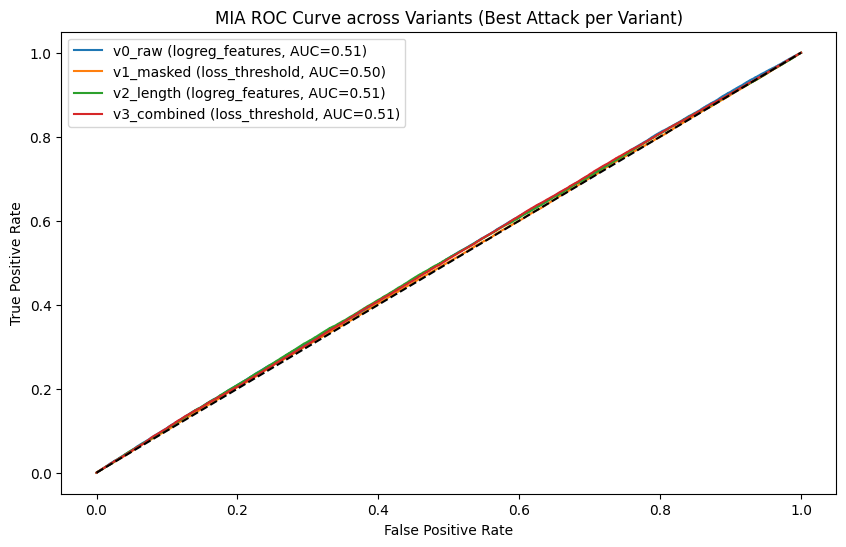


Enhanced MIA summary


,variant,best_attack,mia_auc,attack_advantage,tpr@1%fpr,tpr@5%fpr,loss_auc,logreg_auc
1,v1_masked,loss_threshold,0.501745,0.003490,0.010724,0.050562,0.501745,0.500509
3,v3_combined,loss_threshold,0.506947,0.013893,0.010642,0.052072,0.506947,0.500832
2,v2_length,logreg_features,0.507252,0.014503,0.010288,0.053593,0.506550,0.507252
0,v0_raw,logreg_features,0.508094,0.016189,0.011060,0.053479,0.493697,0.508094


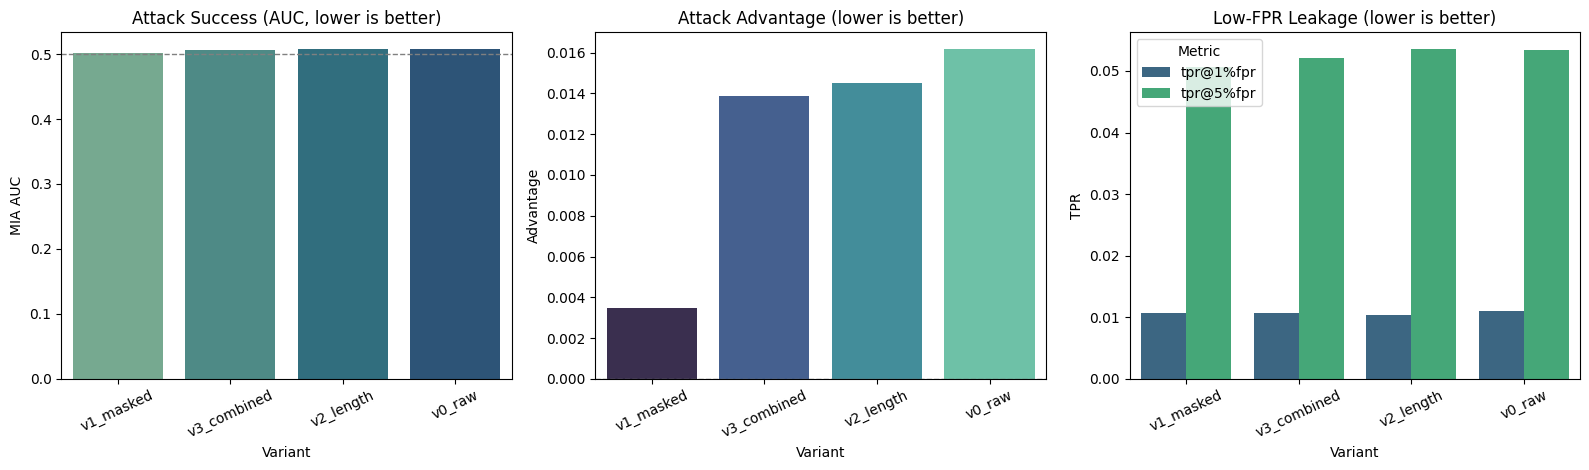

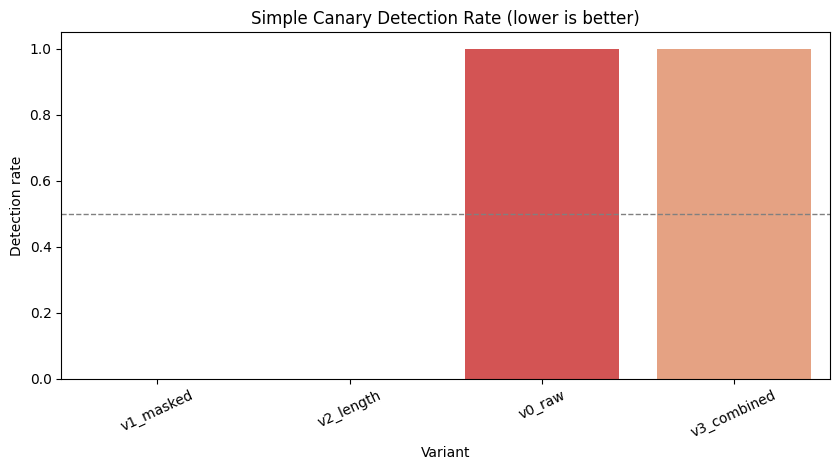

In [10]:
if mia_results_all:
    plt.figure(figsize=(10, 6))
    for r in mia_results_all:
        plt.plot(r['fpr'], r['tpr'], label=f"{r['variant']} ({r['best_attack']}, AUC={r['mia_auc']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('MIA ROC Curve across Variants (Best Attack per Variant)')
    plt.legend()
    plt.show()

    mia_display = pd.DataFrame([
        {
            'variant': r['variant'],
            'best_attack': r['best_attack'],
            'mia_auc': r['mia_auc'],
            'attack_advantage': r['mia_attack_advantage'],
            'tpr@1%fpr': r['tpr_at_fpr_1pct'],
            'tpr@5%fpr': r['tpr_at_fpr_5pct'],
            'loss_auc': r['loss_auc'],
            'logreg_auc': r['logreg_auc']
        }
        for r in mia_results_all
    ]).sort_values('mia_auc')

    print('\nEnhanced MIA summary')
    display(mia_display)

    plot_df = mia_display.copy()
    plot_df['variant'] = pd.Categorical(
        plot_df['variant'],
        categories=plot_df['variant'].tolist(),
        ordered=True
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    sns.barplot(data=plot_df, x='variant', y='mia_auc', ax=axes[0], palette='crest')
    axes[0].axhline(0.5, linestyle='--', color='gray', linewidth=1)
    axes[0].set_title('Attack Success (AUC, lower is better)')
    axes[0].set_xlabel('Variant')
    axes[0].set_ylabel('MIA AUC')
    axes[0].tick_params(axis='x', rotation=25)

    sns.barplot(data=plot_df, x='variant', y='attack_advantage', ax=axes[1], palette='mako')
    axes[1].axhline(0.0, linestyle='--', color='gray', linewidth=1)
    axes[1].set_title('Attack Advantage (lower is better)')
    axes[1].set_xlabel('Variant')
    axes[1].set_ylabel('Advantage')
    axes[1].tick_params(axis='x', rotation=25)

    low_fpr_df = plot_df.melt(
        id_vars=['variant'],
        value_vars=['tpr@1%fpr', 'tpr@5%fpr'],
        var_name='metric',
        value_name='value'
    )
    sns.barplot(data=low_fpr_df, x='variant', y='value', hue='metric', ax=axes[2], palette='viridis')
    axes[2].set_title('Low-FPR Leakage (lower is better)')
    axes[2].set_xlabel('Variant')
    axes[2].set_ylabel('TPR')
    axes[2].tick_params(axis='x', rotation=25)
    axes[2].legend(title='Metric')

    plt.tight_layout()
    plt.show()

    if 'canary_results_all' in globals() and len(canary_results_all) > 0:
        canary_df = pd.DataFrame(canary_results_all).sort_values('canary_detection_rate')
        plt.figure(figsize=(8.5, 4.8))
        sns.barplot(data=canary_df, x='variant', y='canary_detection_rate', palette='rocket')
        plt.axhline(0.5, linestyle='--', color='gray', linewidth=1)
        plt.title('Simple Canary Detection Rate (lower is better)')
        plt.xlabel('Variant')
        plt.ylabel('Detection rate')
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

## Valid Canary Protocol: Insert, Retrain, and Measure Exposure
This section implements a valid canary memorization test by inserting unique canaries into the training set, retraining, and comparing canary vs control exposure.

In [11]:
from sklearn.metrics import roc_auc_score


def insert_train_canaries(train_texts, train_labels, num_canaries=200, target_label=0, seed=42):
    rng = np.random.default_rng(seed)
    train_texts = np.asarray(train_texts, dtype=object)
    train_labels = np.asarray(train_labels, dtype=np.float32)

    canary_suffixes = rng.integers(100000, 999999, size=num_canaries)
    canary_texts = [
        f"[UNIQUE_CANARY_{s}] patient id {s} reports private symptoms and mood shift"
        for s in canary_suffixes
    ]

    canary_labels = np.zeros((num_canaries, train_labels.shape[1]), dtype=np.float32)
    target_label = int(np.clip(target_label, 0, train_labels.shape[1] - 1))
    canary_labels[:, target_label] = 1.0

    aug_texts = np.concatenate([train_texts, np.array(canary_texts, dtype=object)])
    aug_labels = np.vstack([train_labels, canary_labels])
    return aug_texts.tolist(), aug_labels, canary_texts, canary_labels


def build_control_texts(canary_texts):
    return [text.replace('[UNIQUE_CANARY_', '[CONTROL_CANARY_') for text in canary_texts]


def fine_tune_on_augmented_data(model, tokenizer, train_texts, train_labels, epochs=1, lr=2e-5, batch_size=16, max_samples=6000):
    model = model.to(device)
    model.train()

    if max_samples and len(train_texts) > max_samples:
        idx = np.random.choice(len(train_texts), size=max_samples, replace=False)
        train_texts = np.asarray(train_texts, dtype=object)[idx].tolist()
        train_labels = np.asarray(train_labels, dtype=np.float32)[idx]

    dataset = EmotionDataset(train_texts, train_labels, tokenizer)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    for epoch in range(epochs):
        running_loss = 0.0
        for batch in tqdm(loader, desc=f'Canary retrain epoch {epoch + 1}/{epochs}'):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs
            if logits.shape[1] != labels.shape[1]:
                labels = labels[:, :logits.shape[1]]

            loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.item())

        mean_loss = running_loss / max(len(loader), 1)
        print(f'  Canary retrain loss: {mean_loss:.4f}')

    model.eval()
    return model


def per_sample_loss(model, tokenizer, texts, labels, batch_size=16):
    dataset = EmotionDataset(texts, labels, tokenizer)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    losses = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs
            if logits.shape[1] != y.shape[1]:
                y = y[:, :logits.shape[1]]

            batch_loss = torch.nn.functional.binary_cross_entropy_with_logits(
                logits, y, reduction='none'
            ).mean(dim=1)
            losses.extend(batch_loss.detach().cpu().numpy())

    return np.asarray(losses, dtype=np.float32)


def run_valid_canary_protocol_for_variant(variant, seed=42, num_canaries=200, retrain_epochs=1):
    model_ref = resolve_checkpoint_dir(variant) or (Path(MODEL_DIR) / variant_to_model[variant])
    if not Path(model_ref).exists():
        print(f'  Missing model for {variant}: {model_ref}')
        return None

    model, tokenizer, num_labels = load_model_and_tokenizer(model_ref)
    if model is None:
        return None

    train_texts, train_labels = mia_datasets[variant]['train']
    aug_texts, aug_labels, canary_texts, canary_labels = insert_train_canaries(
        train_texts, train_labels, num_canaries=num_canaries, target_label=0, seed=seed
    )

    control_texts = build_control_texts(canary_texts)
    control_labels = canary_labels.copy()

    model = fine_tune_on_augmented_data(
        model, tokenizer, aug_texts, aug_labels, epochs=retrain_epochs, lr=2e-5, batch_size=16, max_samples=6000
    )

    canary_losses = per_sample_loss(model, tokenizer, canary_texts, canary_labels)
    control_losses = per_sample_loss(model, tokenizer, control_texts, control_labels)

    y_true = np.concatenate([np.ones(len(canary_losses)), np.zeros(len(control_losses))])
    y_score = np.concatenate([-canary_losses, -control_losses])
    exposure_auc = roc_auc_score(y_true, y_score)
    exposure_advantage = float(control_losses.mean() - canary_losses.mean())

    model.cpu()
    torch.cuda.empty_cache()

    return {
        'variant': variant,
        'seed': int(seed),
        'num_canaries': int(num_canaries),
        'canary_mean_loss': float(canary_losses.mean()),
        'control_mean_loss': float(control_losses.mean()),
        'exposure_auc': float(exposure_auc),
        'exposure_advantage': exposure_advantage
    }


RUN_VALID_CANARY_PROTOCOL = True
CANARY_VARIANTS = ['v0_raw', 'v1_masked', 'v2_length', 'v3_combined']
CANARY_SEEDS = (7, 13, 23)

if RUN_VALID_CANARY_PROTOCOL:
    valid_canary_rows = []
    for seed in CANARY_SEEDS:
        print(f'\n=== Valid canary protocol, seed {seed} ===')
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        for variant in CANARY_VARIANTS:
            print(f'\nRunning valid canary protocol for {variant}')
            out = run_valid_canary_protocol_for_variant(
                variant, seed=seed, num_canaries=200, retrain_epochs=1
            )
            if out is not None:
                valid_canary_rows.append(out)
                print(f"  Exposure AUC: {out['exposure_auc']:.4f} | Advantage: {out['exposure_advantage']:.6f}")

    if valid_canary_rows:
        valid_canary_df = pd.DataFrame(valid_canary_rows)
        valid_canary_df.to_csv(os.path.join(REPORT_DIR, 'rq3_valid_canary_protocol_results.csv'), index=False)
        print('\nSaved valid canary protocol results to rq3_valid_canary_protocol_results.csv')
        print(valid_canary_df)
else:
    print('Set RUN_VALID_CANARY_PROTOCOL = True to execute the train-inserted canary protocol.')


=== Valid canary protocol, seed 7 ===

Running valid canary protocol for v0_raw


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Canary retrain epoch 1/1: 100%|██████████| 375/375 [00:32<00:00, 11.38it/s]


  Canary retrain loss: 0.2000
  Exposure AUC: 0.3570 | Advantage: -0.000042

Running valid canary protocol for v1_masked


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Canary retrain epoch 1/1: 100%|██████████| 375/375 [00:32<00:00, 11.40it/s]


  Canary retrain loss: 0.1999
  Exposure AUC: 0.1118 | Advantage: -0.000406

Running valid canary protocol for v3_combined


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Canary retrain epoch 1/1: 100%|██████████| 375/375 [00:32<00:00, 11.43it/s]


  Canary retrain loss: 0.2037
  Exposure AUC: 0.3298 | Advantage: -0.000021

Saved valid canary protocol results to rq3_valid_canary_protocol_results.csv
        variant  seed  num_canaries  canary_mean_loss  control_mean_loss  \
0        v0_raw     7           200          0.135517           0.135475   
1     v1_masked     7           200          0.139994           0.139933   
2     v2_length     7           200          0.136388           0.136486   
3   v3_combined     7           200          0.136626           0.136439   
4        v0_raw    13           200          0.132673           0.132700   
5     v1_masked    13           200          0.141845           0.141988   
6     v2_length    13           200          0.138311           0.138325   
7   v3_combined    13           200          0.132524           0.132528   
8        v0_raw    23           200          0.136591           0.136507   
9     v1_masked    23           200          0.145358           0.145377   
10    v2_l

## Statistical Robustness: Multi-Seed Attack Stability
This section estimates 95% confidence intervals and paired significance for MIA (and canary exposure when available).


=== RQ3 MIA seed 7 ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting v0_raw_seed_7 test features: 100%|██████████| 188/188 [00:05<00:00, 32.19it/s]


  v0_raw: best=logreg_features AUC=0.5096 Adv=0.0192


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting v2_length_seed_23 test features: 100%|██████████| 188/188 [00:05<00:00, 32.34it/s]


  v2_length: best=logreg_features AUC=0.4863 Adv=-0.0275


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting v3_combined_seed_23 test features: 100%|██████████| 188/188 [00:05<00:00, 32.51it/s]


  v3_combined: best=logreg_features AUC=0.5045 Adv=0.0091

RQ3 multi-seed MIA runs
    seed      variant   mia_auc  mia_attack_advantage  tpr_at_fpr_1pct  \
0      7       v0_raw  0.509615              0.019231         0.007619   
1      7    v1_masked  0.512000              0.024000         0.014286   
2      7    v2_length  0.503205              0.006411         0.008571   
3      7  v3_combined  0.500135              0.000270         0.006667   
4     13       v0_raw  0.519024              0.038048         0.008571   
5     13    v1_masked  0.503131              0.006261         0.006667   
6     13    v2_length  0.484536             -0.030929         0.005714   
7     13  v3_combined  0.488084             -0.023832         0.006667   
8     23       v0_raw  0.518102              0.036205         0.013333   
9     23    v1_masked  0.510161              0.020322         0.011429   
10    23    v2_length  0.486260             -0.027480         0.007619   
11    23  v3_combined  0.5045

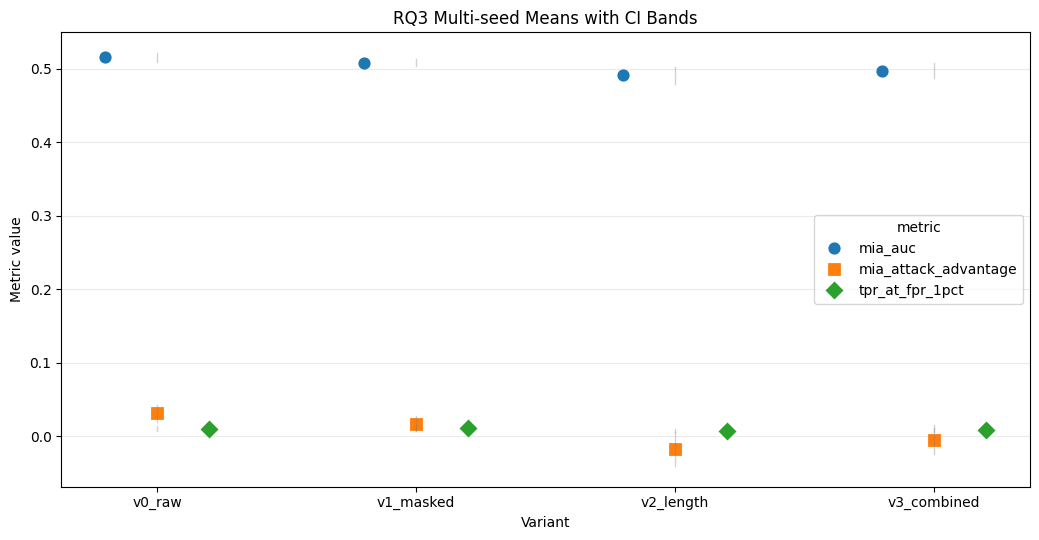

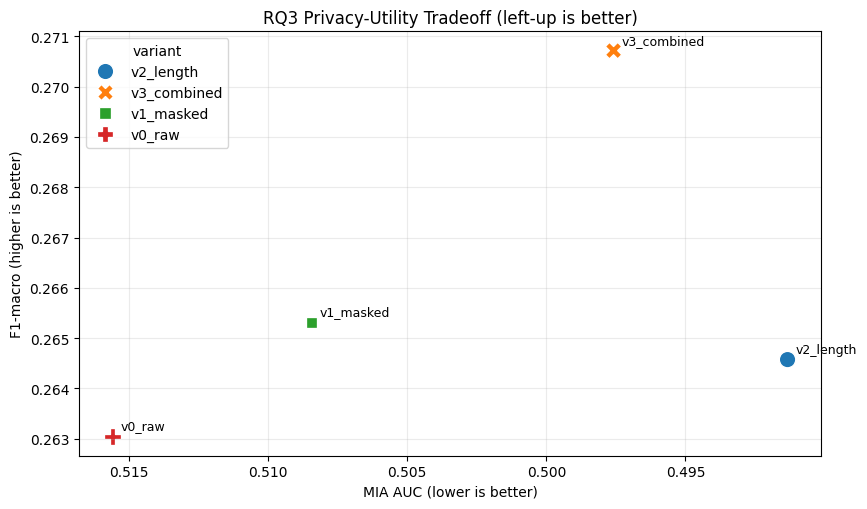

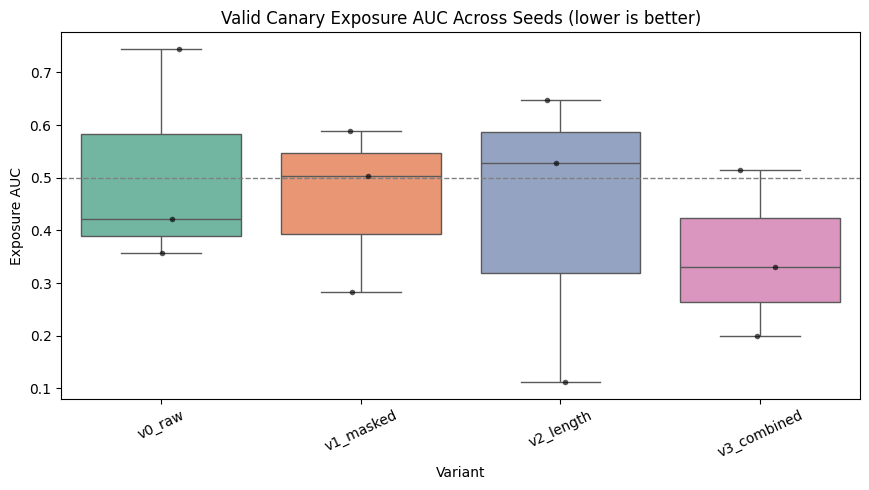

In [12]:
import math
from pathlib import Path


def _ci95(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = float(arr.mean())
    if n == 1:
        return mean, mean, mean
    std = float(arr.std(ddof=1))
    se = std / math.sqrt(n)
    crit = 1.959963984540054
    return mean, mean - crit * se, mean + crit * se


def _paired_signflip_pvalue(diffs, n_perm=10000, seed=42):
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[~np.isnan(diffs)]
    if len(diffs) == 0:
        return np.nan
    rng = np.random.default_rng(seed)
    obs = abs(float(diffs.mean()))
    signs = rng.choice([-1.0, 1.0], size=(n_perm, len(diffs)))
    sims = np.abs((signs * diffs).mean(axis=1))
    return float((np.sum(sims >= obs) + 1) / (n_perm + 1))


def _paired_variant_test(seed_df, metric, variant_a, variant_b, lower_is_better=True):
    pair = seed_df[seed_df['variant'].isin([variant_a, variant_b])][['seed', 'variant', metric]]
    pair = pair.pivot(index='seed', columns='variant', values=metric).dropna()
    if pair.empty:
        return {
            'metric': metric,
            'comparison': f'{variant_a} vs {variant_b}',
            'n_pairs': 0,
            'effect_mean': np.nan,
            'p_value': np.nan,
            'better_direction': 'unavailable'
        }

    a_vals = pair[variant_a].values
    b_vals = pair[variant_b].values
    oriented_diff = (b_vals - a_vals) if lower_is_better else (a_vals - b_vals)
    p_value = _paired_signflip_pvalue(oriented_diff, n_perm=20000, seed=42)
    effect = float(np.mean(oriented_diff))
    better_direction = variant_a if effect > 0 else variant_b

    return {
        'metric': metric,
        'comparison': f'{variant_a} vs {variant_b}',
        'n_pairs': int(len(oriented_diff)),
        'effect_mean': effect,
        'p_value': p_value,
        'better_direction': better_direction
    }


def _seeded_subsample_mia_data(base_data, seed=42, max_per_class=3000):
    """
    Keep membership definition fixed, vary attack sample with seed.
    """
    rng = np.random.default_rng(seed)
    train_texts, train_labels = base_data['train']
    test_texts, test_labels = base_data['test']

    n_train = min(len(train_texts), max_per_class)
    n_test = min(len(test_texts), max_per_class)

    train_idx = rng.choice(len(train_texts), size=n_train, replace=False)
    test_idx = rng.choice(len(test_texts), size=n_test, replace=False)

    train_data = (np.asarray(train_texts, dtype=object)[train_idx], np.asarray(train_labels)[train_idx])
    test_data = (np.asarray(test_texts, dtype=object)[test_idx], np.asarray(test_labels)[test_idx])
    return train_data, test_data


def _build_privacy_utility_tradeoff(mia_summary_df, rq1_eval_path):
    if mia_summary_df is None or mia_summary_df.empty:
        return pd.DataFrame()

    rq1_path = Path(rq1_eval_path)
    if not rq1_path.exists():
        print(f'Utility file not found: {rq1_path}')
        return pd.DataFrame()

    util_df = pd.read_csv(rq1_path)
    util_map = {
        'v0_raw': 'V0_BASELINE',
        'v1_masked': 'V1_ANONYM',
        'v2_length': 'V2_DP_SGD',
        'v3_combined': 'V3_HYBRID'
    }
    util_df['variant'] = util_df['variant'].map({v: k for k, v in util_map.items()})

    merged = mia_summary_df.merge(
        util_df[['variant', 'f1_macro', 'f1_micro', 'precision', 'recall']],
        on='variant',
        how='left'
    )

    merged['privacy_utility_ratio'] = merged['mia_auc'] / merged['f1_macro'].clip(lower=1e-6)
    merged = merged.sort_values(['mia_auc', 'privacy_utility_ratio'])
    return merged


def run_rq3_multiseed_mia(seeds=(7, 13, 23), variants=None, max_per_class=3000):
    if variants is None:
        variants = ['v0_raw', 'v1_masked', 'v2_length', 'v3_combined']

    rows = []
    for seed in seeds:
        print(f'\n=== RQ3 MIA seed {seed} ===')
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        for variant in variants:
            model_ref = resolve_checkpoint_dir(variant) or (Path(MODEL_DIR) / variant_to_model[variant])
            if not Path(model_ref).exists():
                print(f'  Missing model for {variant}: {model_ref}')
                continue

            model, tokenizer, num_labels = load_model_and_tokenizer(model_ref)
            if model is None:
                continue
            model.to(device)

            train_data, test_data = _seeded_subsample_mia_data(
                mia_datasets[variant], seed=seed, max_per_class=max_per_class
            )

            train_features, test_features = extract_mia_features(
                f'{variant}_seed_{seed}', tokenizer, model, train_data, test_data
            )
            suite = evaluate_mia_attack_suite(train_features, test_features, seed=seed)
            if suite is None:
                continue

            best = suite['best_metrics']
            loss_attack = suite['loss_attack']
            logreg_attack = suite['logreg_attack']

            rows.append({
                'seed': int(seed),
                'variant': variant,
                'mia_auc': float(best['auc']),
                'mia_attack_advantage': float(best['advantage']),
                'tpr_at_fpr_1pct': float(best['tpr_at_fpr_1pct']),
                'tpr_at_fpr_5pct': float(best['tpr_at_fpr_5pct']),
                'best_attack': suite['best_attack'],
                'loss_auc': float(loss_attack['auc']),
                'logreg_auc': float(logreg_attack['auc']),
                'train_loss_mean': float(np.mean(train_features[:, 0])),
                'test_loss_mean': float(np.mean(test_features[:, 0]))
            })

            model.cpu()
            torch.cuda.empty_cache()
            print(
                f"  {variant}: best={suite['best_attack']} "
                f"AUC={best['auc']:.4f} Adv={best['advantage']:.4f}"
            )

    return pd.DataFrame(rows)


RUN_RQ3_MULTI_SEED = True
RQ3_SEEDS = (7, 13, 23)

if RUN_RQ3_MULTI_SEED:
    rq3_seed_df = run_rq3_multiseed_mia(seeds=RQ3_SEEDS)

    report_dir = Path(REPORT_DIR)
    report_dir.mkdir(parents=True, exist_ok=True)
    rq3_seed_df.to_csv(report_dir / 'rq3_multiseed_mia_runs.csv', index=False)

    ci_rows = []
    for variant, g in rq3_seed_df.groupby('variant'):
        for metric in [
            'mia_auc',
            'mia_attack_advantage',
            'tpr_at_fpr_1pct',
            'tpr_at_fpr_5pct',
            'train_loss_mean',
            'test_loss_mean'
        ]:
            mean, lo, hi = _ci95(g[metric].values)
            ci_rows.append({
                'variant': variant,
                'metric': metric,
                'mean': mean,
                'ci95_low': lo,
                'ci95_high': hi,
                'n': int(g[metric].notna().sum())
            })
    rq3_ci_df = pd.DataFrame(ci_rows)
    rq3_ci_df.to_csv(report_dir / 'rq3_multiseed_mia_ci_summary.csv', index=False)

    sig_rows = [
        _paired_variant_test(rq3_seed_df, 'mia_auc', 'v3_combined', 'v0_raw', lower_is_better=True),
        _paired_variant_test(rq3_seed_df, 'mia_auc', 'v3_combined', 'v2_length', lower_is_better=True),
        _paired_variant_test(rq3_seed_df, 'mia_auc', 'v3_combined', 'v1_masked', lower_is_better=True),
        _paired_variant_test(rq3_seed_df, 'tpr_at_fpr_1pct', 'v3_combined', 'v0_raw', lower_is_better=True),
        _paired_variant_test(rq3_seed_df, 'tpr_at_fpr_1pct', 'v3_combined', 'v2_length', lower_is_better=True),
        _paired_variant_test(rq3_seed_df, 'mia_attack_advantage', 'v3_combined', 'v0_raw', lower_is_better=True),
        _paired_variant_test(rq3_seed_df, 'mia_attack_advantage', 'v3_combined', 'v2_length', lower_is_better=True)
    ]

    # Add canary exposure significance if valid canary protocol has been run
    if 'valid_canary_df' in globals() and not valid_canary_df.empty:
        for comp in ['v0_raw', 'v1_masked', 'v2_length']:
            sub = valid_canary_df[valid_canary_df['variant'].isin(['v3_combined', comp])][['seed', 'variant', 'exposure_auc']]
            sub = sub.pivot(index='seed', columns='variant', values='exposure_auc').dropna()
            if not sub.empty:
                diffs = sub[comp].values - sub['v3_combined'].values
                sig_rows.append({
                    'metric': 'exposure_auc',
                    'comparison': f'v3_combined vs {comp}',
                    'n_pairs': int(len(diffs)),
                    'effect_mean': float(np.mean(diffs)),
                    'p_value': _paired_signflip_pvalue(diffs, n_perm=20000, seed=42),
                    'better_direction': 'v3_combined' if np.mean(diffs) > 0 else comp
                })

    rq3_sig_df = pd.DataFrame(sig_rows)
    rq3_sig_df.to_csv(report_dir / 'rq3_multiseed_significance.csv', index=False)

    summary = rq3_seed_df.groupby('variant', as_index=False).agg(
        mia_auc=('mia_auc', 'mean'),
        mia_attack_advantage=('mia_attack_advantage', 'mean'),
        tpr_at_fpr_1pct=('tpr_at_fpr_1pct', 'mean'),
        tpr_at_fpr_5pct=('tpr_at_fpr_5pct', 'mean')
    )
    tradeoff_df = _build_privacy_utility_tradeoff(
        summary,
        Path(PROJECT_ROOT) / 'reports' / 'rq1' / 'rq1_evaluation.csv'
    )
    if not tradeoff_df.empty:
        tradeoff_df.to_csv(report_dir / 'rq3_privacy_utility_tradeoff.csv', index=False)

    print('\nRQ3 multi-seed MIA runs')
    print(rq3_seed_df)
    print('\nRQ3 CI summary')
    print(rq3_ci_df)
    print('\nRQ3 significance tests')
    print(rq3_sig_df)
    if not tradeoff_df.empty:
        print('\nRQ3 privacy-utility tradeoff table')
        print(tradeoff_df)

    if not rq3_ci_df.empty:
        ci_focus = rq3_ci_df[rq3_ci_df['metric'].isin(['mia_auc', 'mia_attack_advantage', 'tpr_at_fpr_1pct'])].copy()
        if not ci_focus.empty:
            plt.figure(figsize=(10.5, 5.5))
            sns.pointplot(
                data=ci_focus,
                x='variant',
                y='mean',
                hue='metric',
                dodge=0.4,
                markers=['o', 's', 'D'],
                linestyles='none'
            )
            for _, row in ci_focus.iterrows():
                x_idx = list(ci_focus['variant'].unique()).index(row['variant'])
                plt.plot([x_idx, x_idx], [row['ci95_low'], row['ci95_high']], color='gray', alpha=0.35, linewidth=1)
            plt.title('RQ3 Multi-seed Means with CI Bands')
            plt.xlabel('Variant')
            plt.ylabel('Metric value')
            plt.grid(axis='y', alpha=0.25)
            plt.tight_layout()
            plt.show()

    if not tradeoff_df.empty:
        plt.figure(figsize=(8.8, 5.2))
        sns.scatterplot(
            data=tradeoff_df,
            x='mia_auc',
            y='f1_macro',
            hue='variant',
            style='variant',
            s=140
        )
        for _, row in tradeoff_df.iterrows():
            plt.annotate(row['variant'], (row['mia_auc'], row['f1_macro']), textcoords='offset points', xytext=(6, 5), fontsize=9)
        plt.gca().invert_xaxis()
        plt.title('RQ3 Privacy-Utility Tradeoff (left-up is better)')
        plt.xlabel('MIA AUC (lower is better)')
        plt.ylabel('F1-macro (higher is better)')
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

    if 'valid_canary_df' in globals() and not valid_canary_df.empty:
        plt.figure(figsize=(8.8, 5.0))
        sns.boxplot(data=valid_canary_df, x='variant', y='exposure_auc', palette='Set2')
        sns.stripplot(data=valid_canary_df, x='variant', y='exposure_auc', color='black', size=4, alpha=0.65)
        plt.axhline(0.5, linestyle='--', color='gray', linewidth=1)
        plt.title('Valid Canary Exposure AUC Across Seeds (lower is better)')
        plt.xlabel('Variant')
        plt.ylabel('Exposure AUC')
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()
else:
    print('Set RUN_RQ3_MULTI_SEED = True to execute cross-seed MIA stability and significance analysis.')